In [33]:
import os

from physics.simulation import msq
from rolypoly import dataset, model

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist
import pandas as pd

import torch
from lightning import Trainer

In [34]:
OUTPUT_DIR = 'jobs/rolypoly/run-one-pytorch/coeff_1'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '..'

checkpoint_epoch = 99
checkpoint_loss = '0.00'

CHECKPOINT = f'checkpoint-rolypoly-epoch={checkpoint_epoch}-val_loss={checkpoint_loss}.ckpt'

VERSION_NO = 15286900
LIGHTNING_DIR = f'lightning_logs/version_{VERSION_NO}'

COMPONENT = msq.Component.SBI

SAMPLE_SIZE = 50000
BATCH_SIZE = 64
SEED = 42

In [35]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

component_names = {
    msq.Component.SBI : 'SBI',
    msq.Component.SIG : 'SIG',
    msq.Component.INT : 'INT',
    msq.Component.BKG : 'BKG'
}

In [36]:
training_data = dataset.RolypolyDataModule(data_dir=SAMPLE_DIR,
                                           sample_file=filenames[COMPONENT],
                                           sample_xs=xs[COMPONENT],
                                           sample_baseline=COMPONENT,
                                           scaler_path=os.path.join(OUTPUT_DIR, SCALER_FILE),
                                           sample_size=SAMPLE_SIZE,
                                           batch_size=BATCH_SIZE,
                                           random_state=SEED)

validation_data = dataset.RolypolyDataModule(data_dir=SAMPLE_DIR,
                                             sample_file=filenames[COMPONENT],
                                             sample_xs=xs[COMPONENT],
                                             sample_baseline=COMPONENT,
                                             scaler_path=os.path.join(OUTPUT_DIR, SCALER_FILE),
                                             sample_size=SAMPLE_SIZE,
                                             offset=SAMPLE_SIZE,
                                             batch_size=BATCH_SIZE,
                                             random_state=SEED)

In [37]:
loaded_model = model.ROLYPOLY.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [38]:
trainer = Trainer()
training_predictions = trainer.predict(loaded_model, datamodule=training_data)
validation_predictions = trainer.predict(loaded_model, datamodule=validation_data)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 782/782 [00:20<00:00, 37.54it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 782/782 [00:21<00:00, 36.60it/s]


In [39]:
predictions_train = torch.cat(training_predictions).view(-1)
targets_train = training_data.prediction_data.get_y()

weights_train = training_data.prediction_data.get_weights()

In [40]:
predictions_val = torch.cat(validation_predictions).view(-1)
targets_val = validation_data.prediction_data.get_y()

weights_val = validation_data.prediction_data.get_weights()

In [ ]:
BINS = 60

bounds = [-1.2e-2,5e-3]

h_predictions_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_train.fill(predictions_train, weight=weights_train)

h_targets_train = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_train.fill(targets_train, weight=weights_train)

h_predictions_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_predictions_val.fill(predictions_val, weight=weights_val)

h_targets_val = hist.Hist(hist.axis.Regular(BINS, *bounds))
h_targets_val.fill(targets_val, weight=weights_val)


h_targets_train.plot(color='royalblue', linestyle='--', label='targets (training)', alpha=0.6)
h_predictions_train.plot(color='royalblue', linestyle='-', label='NN predictions (training)')


bin_edges = h_predictions_val.axes[0].edges
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_heights = h_predictions_val.values()

h_targets_val.plot(color='red', linestyle='--', label='targets (validation)', alpha=0.6)
plt.scatter(bin_centers, bin_heights, color='red', marker='o', s=20, label='NN predictions (validation)')

plt.xlabel(f'coeff')
plt.ylabel('number of events')
plt.yscale('log')

plt.legend()

plt.show()

NameError: name 'hist' is not defined

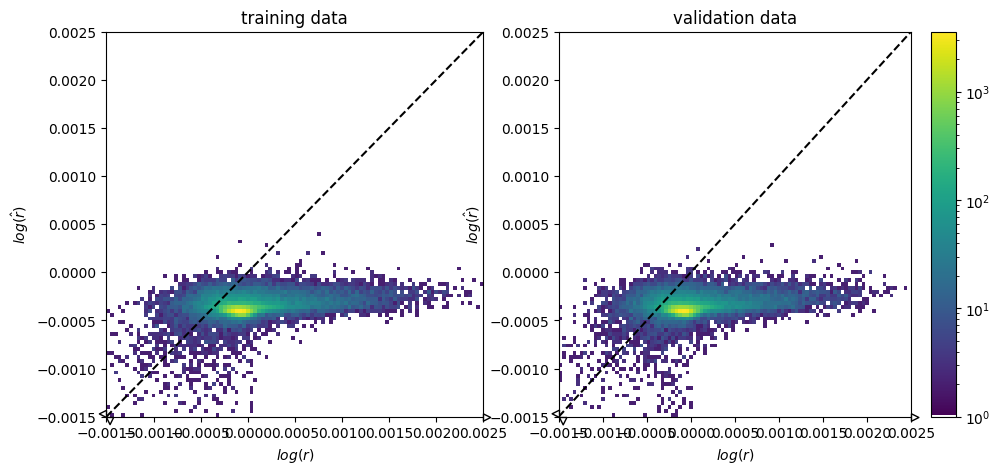

In [54]:
BINS=100

bounds = [-1.5e-3,2.5e-3]

h_calibration_train = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='$log(r)$'),
    hist.axis.Regular(BINS, *bounds, name='$log(\hat{r})$')
)

h_calibration_train.fill(targets_train, predictions_train)

h_calibration_val = hist.Hist(
    hist.axis.Regular(BINS, *bounds, name='$log(r)$'),
    hist.axis.Regular(BINS, *bounds, name='$log(\hat{r})$')
)

h_calibration_val.fill(targets_val, predictions_val)

cmap = colors.ListedColormap(['white'] + plt.cm.viridis.colors[1:])

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))

h_calibration_train.plot2d(ax=ax1, cmap=cmap, cbar=False, norm=LogNorm())
ax1.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

ax1.set_title('training data')

h_calibration_val.plot2d(ax=ax2, cmap=cmap, norm=LogNorm())
ax2.plot(np.linspace(*bounds), np.linspace(*bounds), color='k', linestyle='--')

ax2.set_title('validation data')

plt.show()

In [43]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs, train_loss, color='royalblue', label='training')
plt.plot(epochs, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'jobs/rolypoly/run-one-pytorch/coeff_1/lightning_logs/version_15286900/metrics.csv'